1. Analyze and Preprocess data - Check if the dataset has missing values or has any other problem.
2. Feature Engineering
3. Determine the cluster number
    3. a. Use elbow method as baseline
    3. b. Apply other methods to compare with elbow
4. Use Pipeline
    4. a. Use scaler and dimensional reduction (if it is necessary).
    4. b. Use suitable clustering model for this problem.
5. Visualize your cluster in 2D or 3D to compare the result.
6. Measure performance of your clustering model.
7. Conclusion and Discussion (<= 200 words, also input your opinion or conclusion here)


How can I measure your point:
1. Your function is callable and runs correctly
2. The performance of your model (in full pipeline) is acceptable. The final error based on my train and test set is low enough.
3. The data preprocessing is correct or make sense
4. The Feature engineering is correct or make sense
5. Any other additional process will be considered a small plus point.

| Biến                        | Mô tả                                                                 |
|-----------------------------|----------------------------------------------------------------------|
| `BALANCE`                   | Số dư còn lại trong tài khoản để thực hiện mua sắm                  |
| `BALANCE_FREQUENCY`         | Tần suất cập nhật số dư, giá trị từ 0 đến 1 (1 = cập nhật thường xuyên) |
| `PURCHASES`                 | Tổng số tiền đã mua sắm từ tài khoản                                |
| `ONEOFF_PURCHASES`          | Giá trị lớn nhất của một lần mua hàng đơn lẻ                        |
| `INSTALLMENTS_PURCHASES`    | Tổng giá trị mua hàng theo hình thức trả góp                        |
| `CASH_ADVANCE`              | Số tiền mặt được ứng trước bởi người dùng                           |
| `PURCHASES_FREQUENCY`       | Tần suất thực hiện các giao dịch mua sắm (0 đến 1)                  |
| `ONEOFF_PURCHASES_FREQUENCY`| Tần suất thực hiện các giao dịch mua đơn lẻ (0 đến 1)               |
| `PURCHASES_INSTALLMENTS_FREQUENCY` | Tần suất mua hàng trả góp (0 đến 1)                          |
| `CASH_ADVANCE_FREQUENCY`    | Tần suất ứng trước tiền mặt (0 đến 1)                               |
| `CASH_ADVANCE_TRX`          | Số lượng giao dịch ứng trước tiền mặt                               |
| `PURCHASES_TRX`             | Số lượng giao dịch mua hàng                                         |
| `CREDIT_LIMIT`              | Hạn mức tín dụng của thẻ đối với người dùng                         |
| `PAYMENTS`                  | Tổng số tiền người dùng đã thanh toán                               |
| `MINIMUM_PAYMENTS`          | Khoản thanh toán tối thiểu người dùng đã trả                        |
| `PRC_FULL_PAYMENT`          | Tỷ lệ phần trăm thanh toán toàn bộ nợ                              |
| `TENURE`                    | Thời gian sử dụng thẻ tín dụng của người dùng                       |


**Chỉ dùng các features trên để phân cụm**

# Load Dataset

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("D:/NMMH/Clustered_Customer_Data/Clustered_Customer_Data.csv")

In [ ]:
df.head()

,Unnamed: 0,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,3
3,3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,0
4,4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0


# Data Analysis

In [ ]:
df.describe()

,Unnamed: 0,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,4474.500000,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318,1.442011
std,2583.786788,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.612411,2895.063757,2330.588021,0.292499,1.338331,1.373951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000,0.000000
25%,2237.250000,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,170.857654,0.000000,12.000000,0.000000
50%,4474.500000,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,335.628312,0.000000,12.000000,2.000000
75%,6711.750000,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,864.206542,0.142857,12.000000,3.000000
max,8949.000000,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000,3.000000


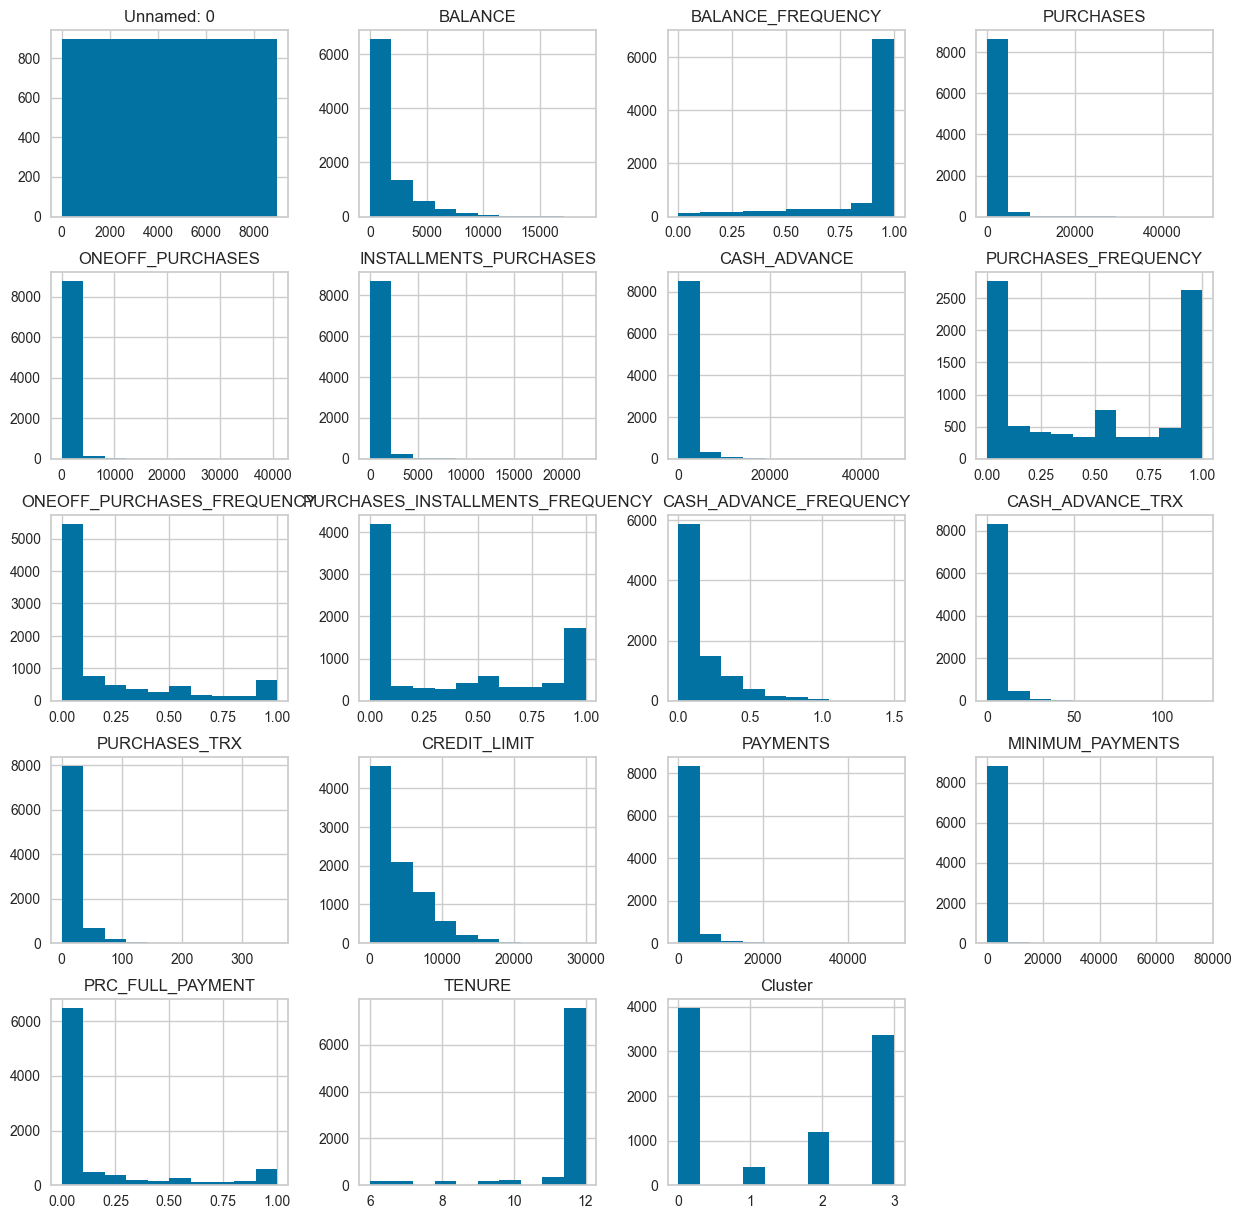

In [ ]:
df.hist(figsize=(15, 15))
plt.show()

In [ ]:
df = df.drop(columns=[df.columns[0]])
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,3
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0


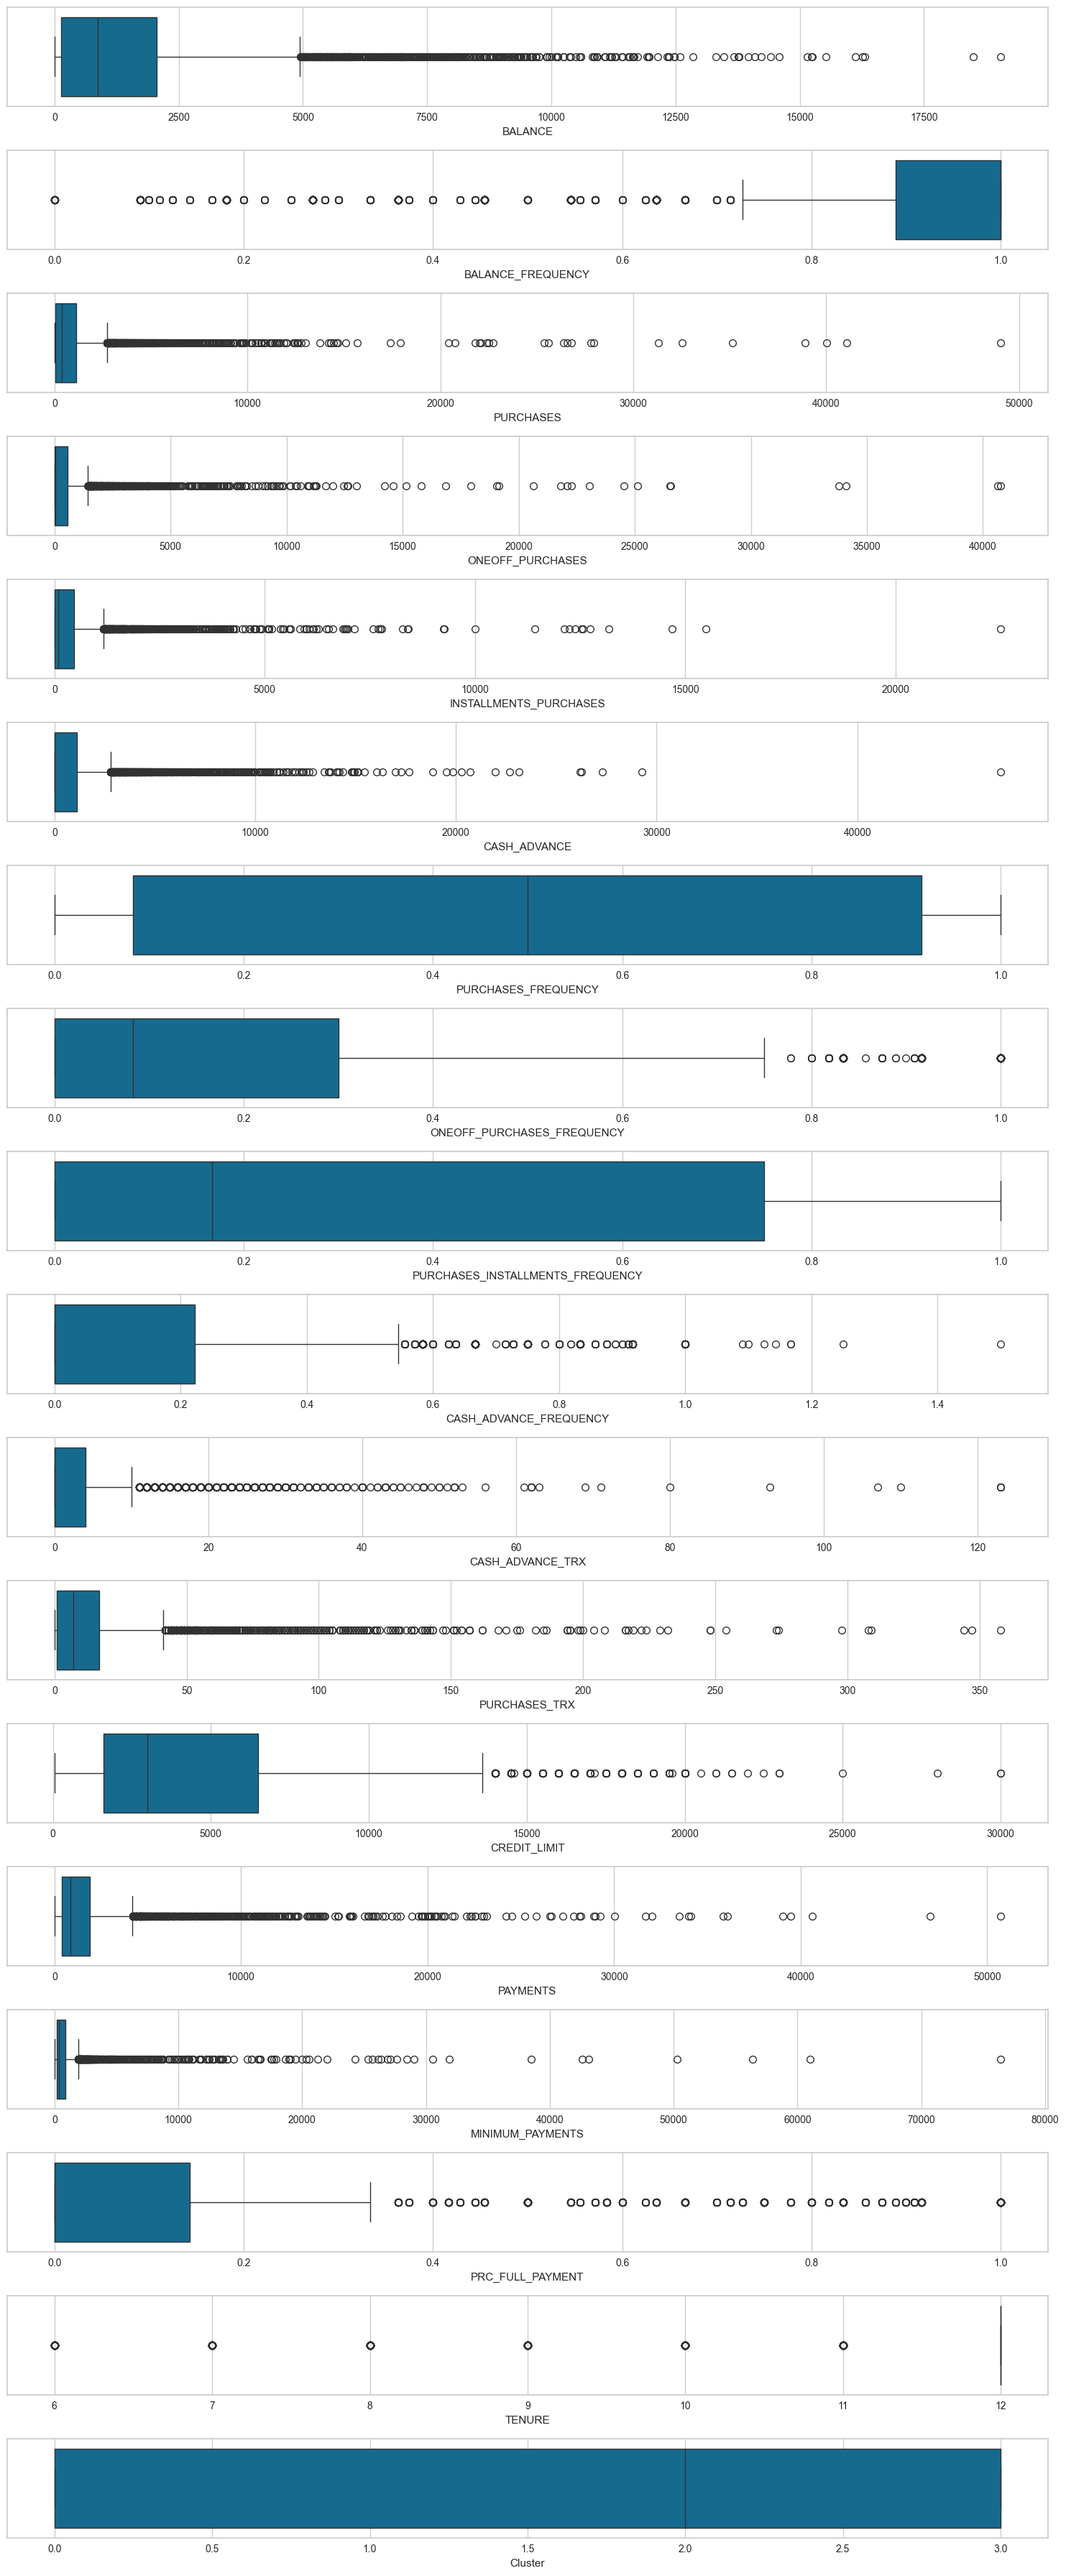

In [ ]:
# boxplot thể hiện các outliers
fig, axes = plt.subplots(len(df.columns), 1, figsize=(15, 2*len(df.columns)))
for i, column in enumerate(df.columns):
    sns.boxplot(x=df[column], ax=axes[i])

plt.tight_layout()
plt.show()

In [ ]:
df.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
Cluster                             0
dtype: int64

# Data Preprocessing

In [ ]:
# Dùng phương pháp IQR để loại bỏ các outliers
excluded_cols = ["TENURE", "Cluster"]
for col in df.columns:
    if col in excluded_cols:
        continue
    if np.issubdtype(df[col].dtype, np.number):
        q1 = np.percentile(df[col], 25)
        q3 = np.percentile(df[col], 75)
        iqr = q3 - q1
        threshold = 1.5 * iqr
        max_value = q3 + threshold
        min_value = q1 - threshold
        df.loc[df[col] > max_value, col] = max_value
        df.loc[df[col] < min_value, col] = min_value
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1390.508973,0.931587,737.149330,354.358139,295.546214,672.468924,0.490351,0.184773,0.364437,0.126061,2.383128,11.623799,4419.304199,1347.084165,593.711582,0.087223,11.517318,1.442011
std,1537.538479,0.110984,879.534788,511.823289,396.181546,998.514970,0.401371,0.255668,0.397448,0.172676,3.417878,13.041645,3383.755481,1272.806272,572.040335,0.138616,1.338331,1.373951
min,0.000000,0.722223,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000,0.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,170.857654,0.000000,12.000000,0.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,335.628312,0.000000,12.000000,2.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,864.206542,0.142857,12.000000,3.000000
max,4942.927215,1.000000,2715.872500,1443.512500,1171.593750,2784.552848,1.000000,0.750000,1.000000,0.555555,10.000000,41.000000,13850.000000,4177.921543,1904.229874,0.357143,12.000000,3.000000


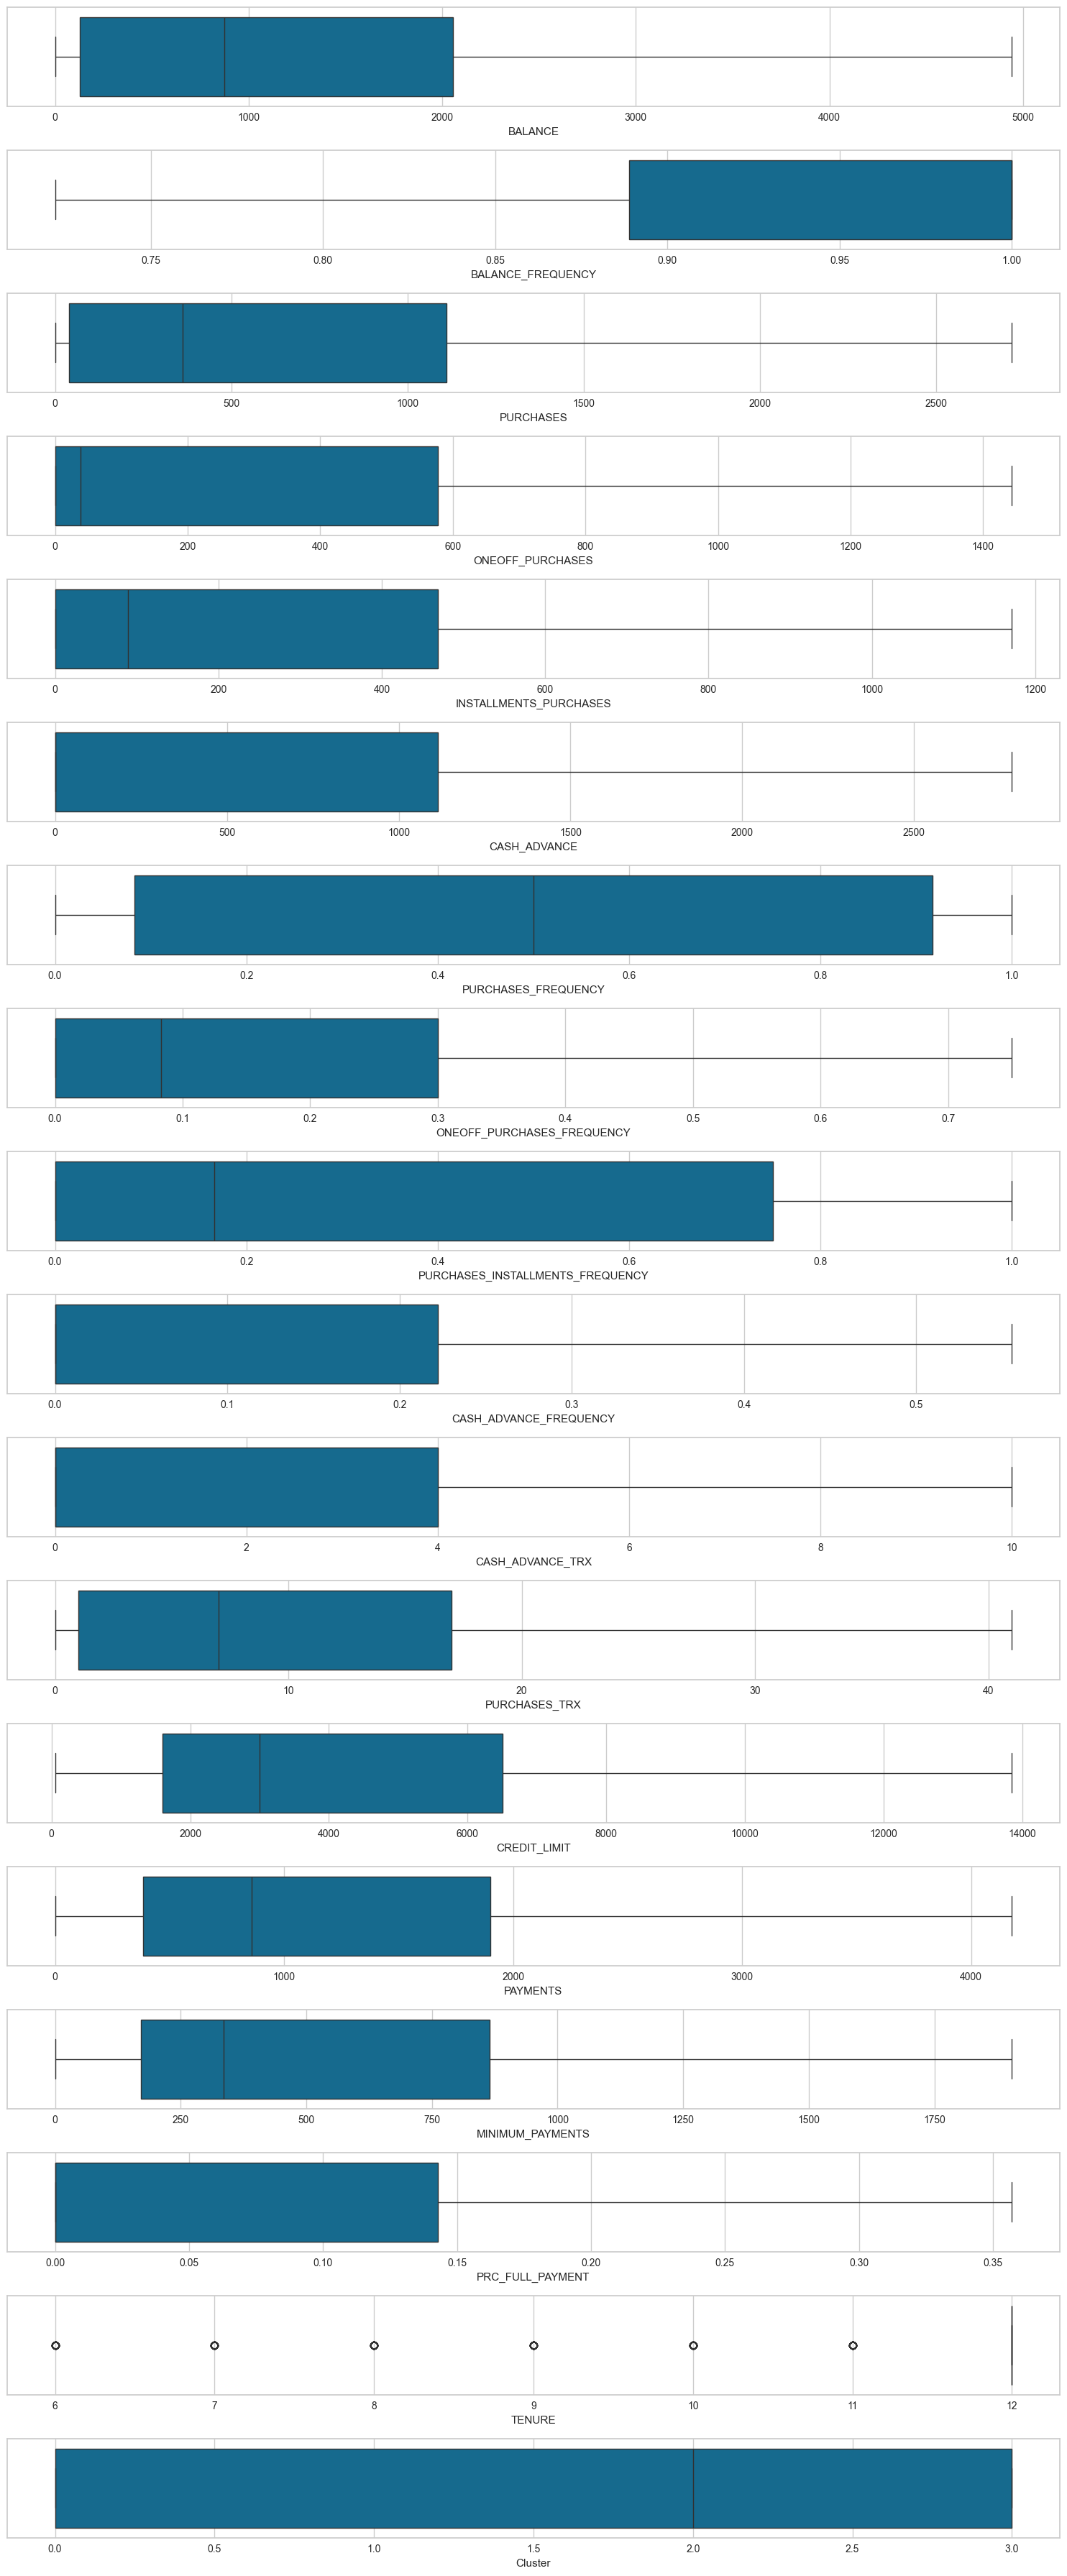

In [ ]:
fig, axes = plt.subplots(len(df.columns), 1, figsize=(15, 2*len(df.columns)))
for i, column in enumerate(df.columns):
    sns.boxplot(x=df[column], ax=axes[i])

plt.tight_layout()
plt.show()

# Feature Engineering

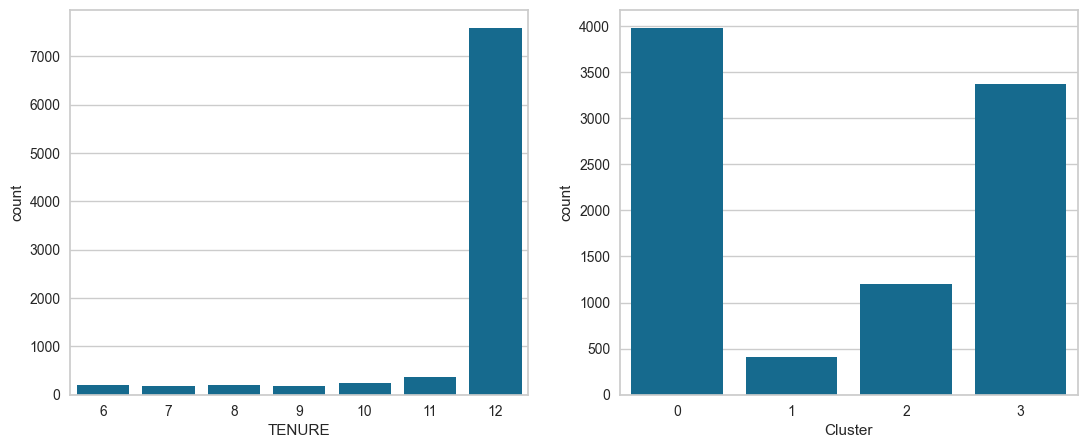

In [ ]:
# countplot cho cột TENURE và Cluster
cat_cols = df[['TENURE', 'Cluster']]
fig, axes = plt.subplots(1, len(cat_cols.columns), figsize=(13, 5))
for i, col in enumerate(cat_cols.columns):
    sns.countplot(x=col, data=df, ax=axes[i])


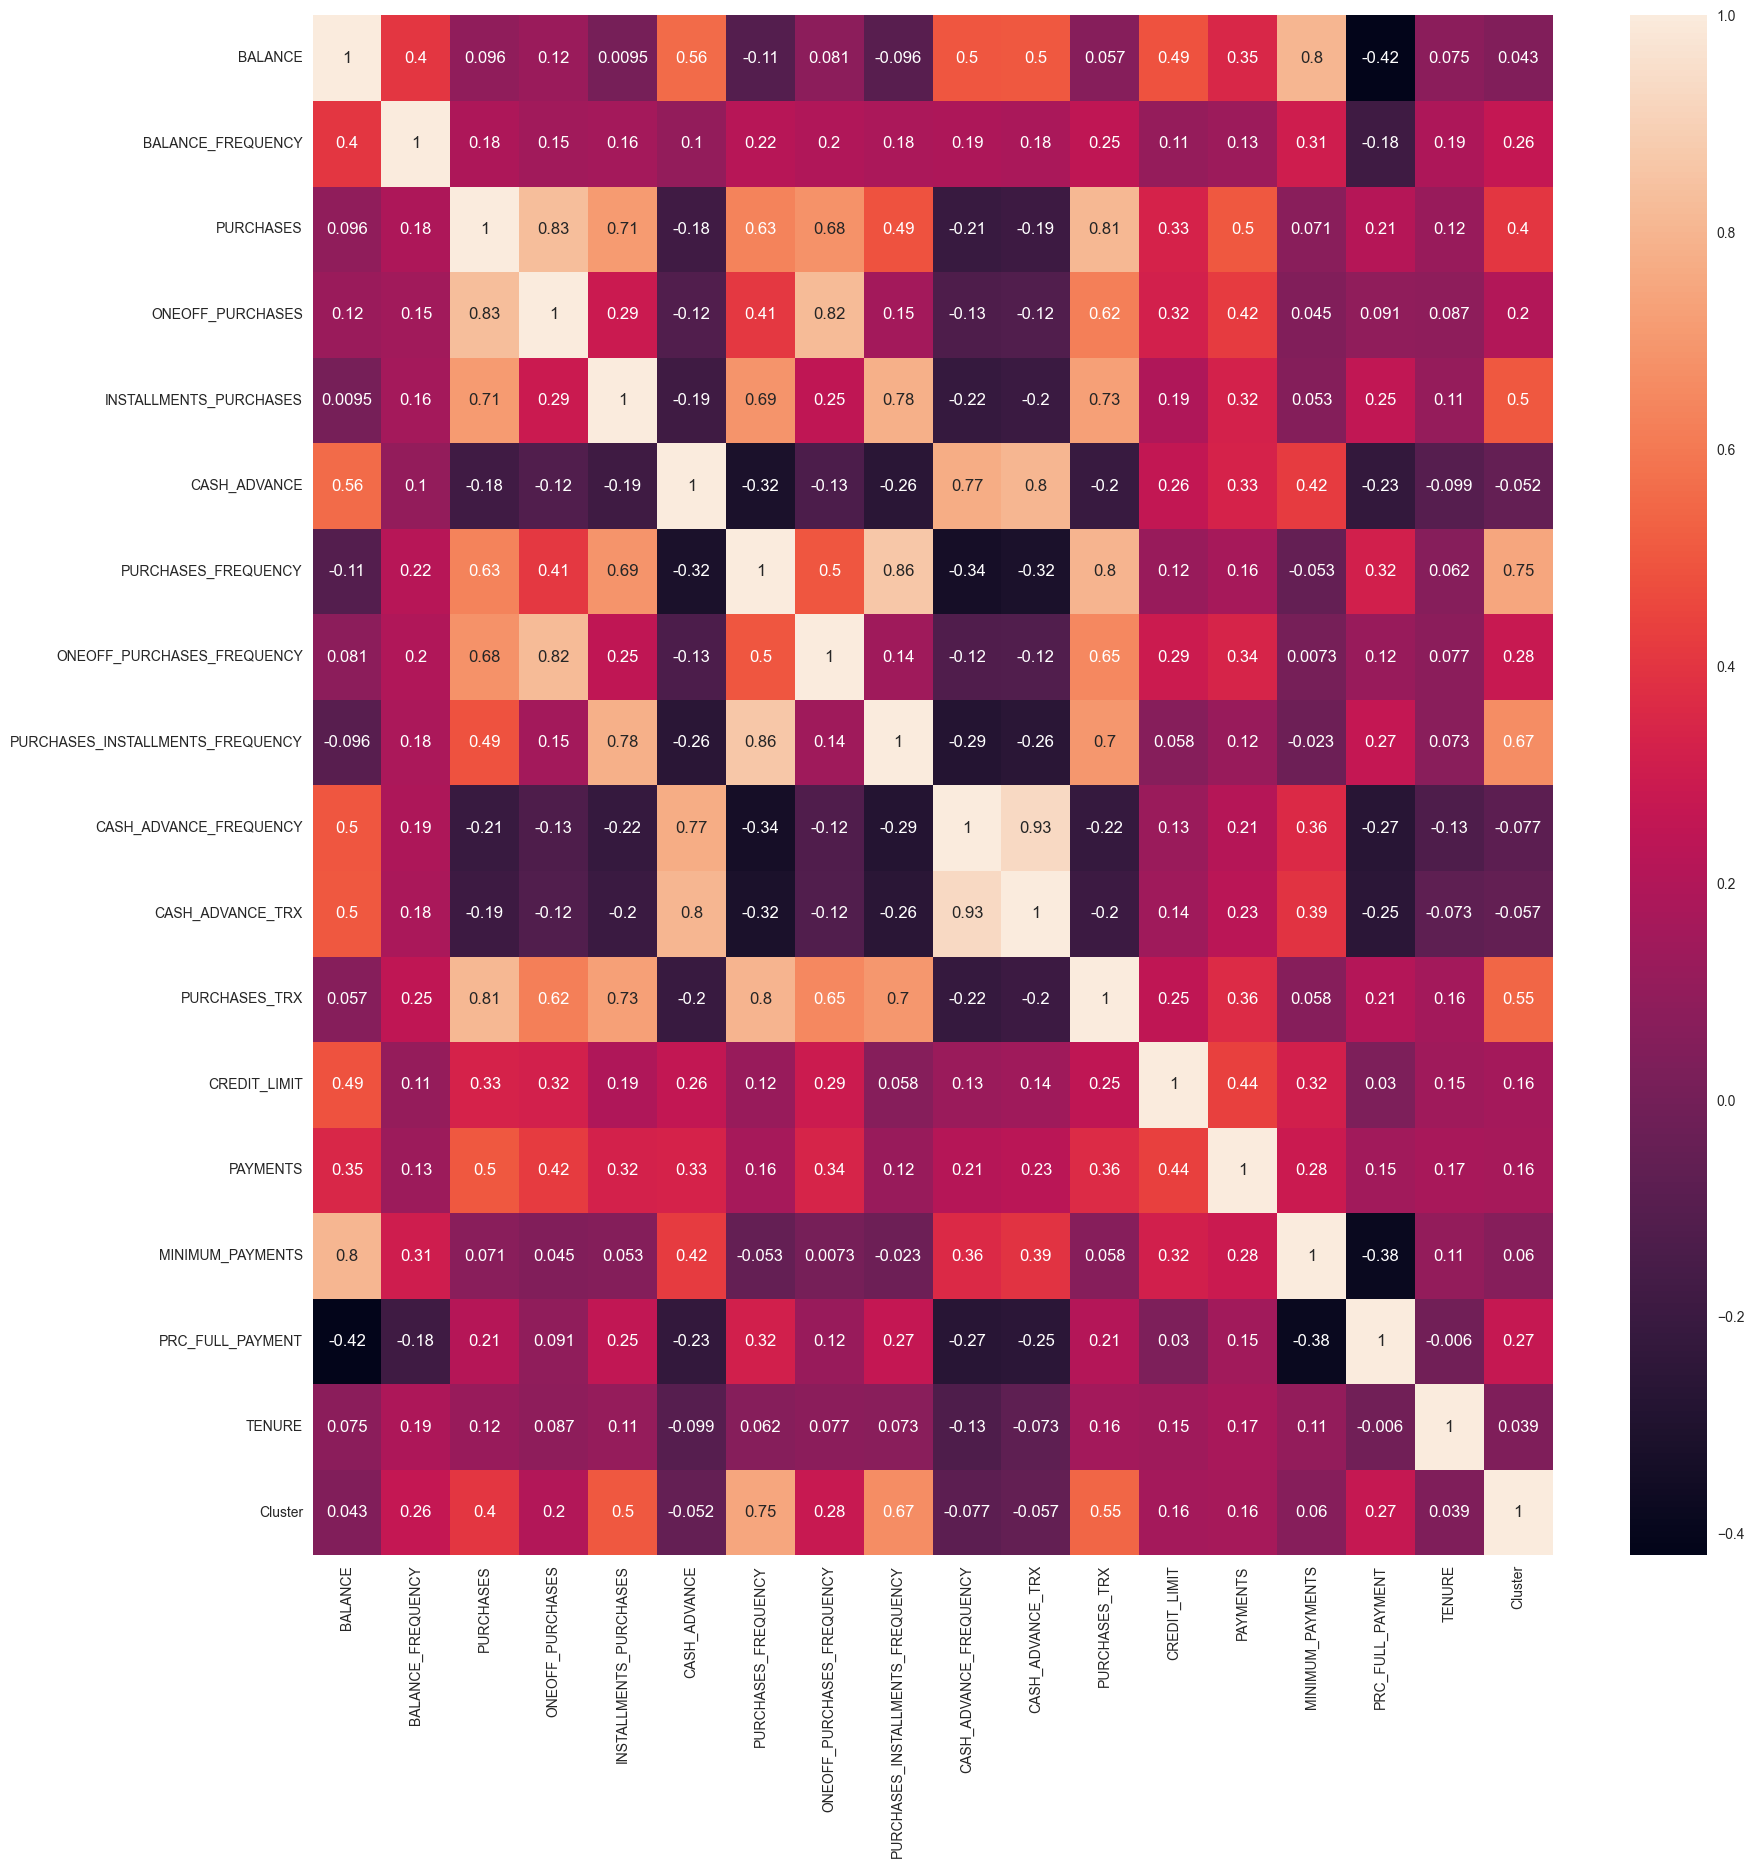

In [ ]:
# heatmap
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
# Loại bỏ cột Cluster
df_ = df.drop(columns = ['Cluster'])
df_.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.0000,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.0000,0.0,2784.552848,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.1700,0.0,0.000000,1.000000,0.750000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.722223,1499.00,1443.5125,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,817.714335,1.000000,16.00,16.0000,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


# Model Part

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_.values)
scaled_data

array([[-0.87782104, -1.02187519, -0.72968709, ..., -0.79404745,
        -0.62927738,  0.36067954],
       [ 1.1785459 , -0.2027079 , -0.83815959, ...,  0.83675109,
         0.9739614 ,  0.36067954],
       [ 0.71848713,  0.61645939,  0.04095652, ...,  0.05869355,
        -0.62927738,  0.36067954],
       ...,
       [-0.88920486, -0.88535181, -0.67397271, ..., -0.89385616,
         1.17436805, -4.12276757],
       [-0.89567082, -0.88535181, -0.83815959, ..., -0.94046866,
         1.17436805, -4.12276757],
       [-0.66200474, -1.88655177,  0.40489651, ..., -0.88359305,
        -0.62927738, -4.12276757]])

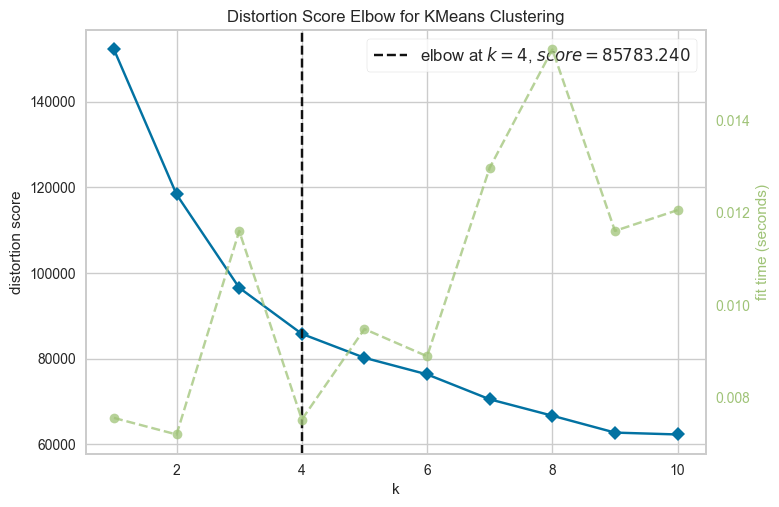

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

elbow_method = KElbowVisualizer(KMeans(), k=(1,11))
elbow_method.fit(scaled_data)
elbow_method.show()

In [ ]:
kmeans_model = KMeans(n_clusters=4)
kmeans_model.fit(scaled_data)

KMeans(n_clusters=4)

In [ ]:
kmeans_model.predict(scaled_data)

array([0, 2, 1, ..., 3, 0, 0], dtype=int32)

In [ ]:
kmeans_model.cluster_centers_

array([[-0.36308289, -0.37139787, -0.54417562, -0.29067667, -0.63247472,
        -0.29956948, -0.75340468, -0.29272684, -0.73147709, -0.24323322,
        -0.29267693, -0.65130896, -0.37334656, -0.46105623, -0.30742411,
        -0.29769402, -0.04588103],
       [ 0.30133762,  0.43153101,  1.67588599,  1.6077349 ,  0.9877737 ,
        -0.25689099,  1.01790129,  1.51125115,  0.68264811, -0.3015728 ,
        -0.28167408,  1.50909856,  0.70302776,  0.93512294,  0.15281298,
         0.2795139 ,  0.25878302],
       [ 1.11515923,  0.32153037, -0.51257186, -0.36817221, -0.48621132,
         1.49688295, -0.66492287, -0.36436453, -0.56891454,  1.45142706,
         1.50552886, -0.55077335,  0.4848618 ,  0.47964044,  0.87767663,
        -0.41658112, -0.10540482],
       [-0.59311025, -0.03013916, -0.03867816, -0.48984224,  0.60163856,
        -0.57419133,  0.90866862, -0.41584659,  1.05382838, -0.58827091,
        -0.57273829,  0.28330445, -0.369221  , -0.40969961, -0.36919501,
         0.57918772

## 3 dimensional PCA 

In [ ]:
pca = PCA(n_components=3)
pca_df = pd.DataFrame(pca.fit_transform(scaled_data), columns=["pca_1", "pca_2", "pca_3"])

In [ ]:
pca.explained_variance_ratio_

array([0.31561234, 0.23665552, 0.09074732])

In [ ]:
pca_df.head()

,pca_1,pca_2,pca_3
0,-1.624789,-2.381615,-0.255016
1,-2.158390,2.289497,-0.557901
2,1.198983,0.280708,-1.535004
3,-0.495849,-0.185931,-2.271893
4,-1.632622,-1.597279,-0.210639


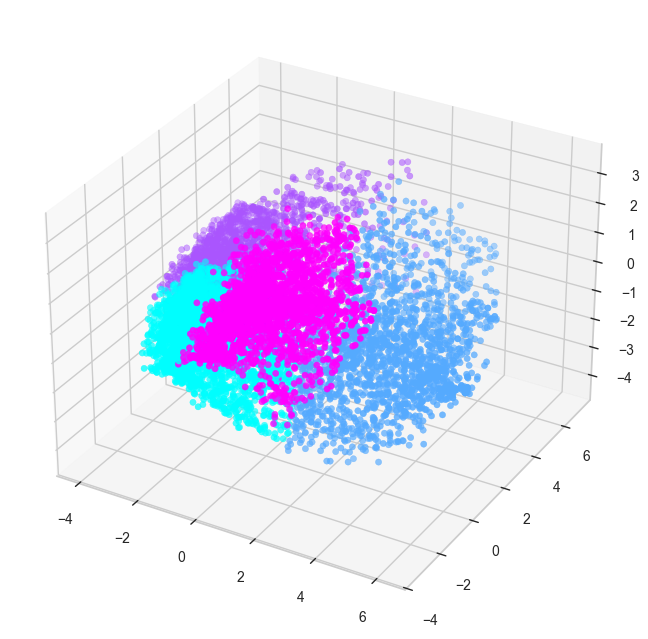

In [ ]:
plt.figure(figsize=(8, 13))
ax = plt.subplot(projection="3d")
ax.scatter(pca_df.pca_1, pca_df.pca_2, pca_df.pca_3, c=kmeans_model.labels_, cmap='cool')
plt.show()

## 2 dimensional PCA 

In [ ]:
pca = PCA(n_components=2)
pca_df = pd.DataFrame(pca.fit_transform(scaled_data), columns=["pca1", "pca2"])

In [ ]:
pca.explained_variance_ratio_

array([0.31561234, 0.23665552])

In [ ]:
pca_df.head()

,pca1,pca2
0,-1.624789,-2.381615
1,-2.158390,2.289497
2,1.198983,0.280708
3,-0.495849,-0.185931
4,-1.632622,-1.597279


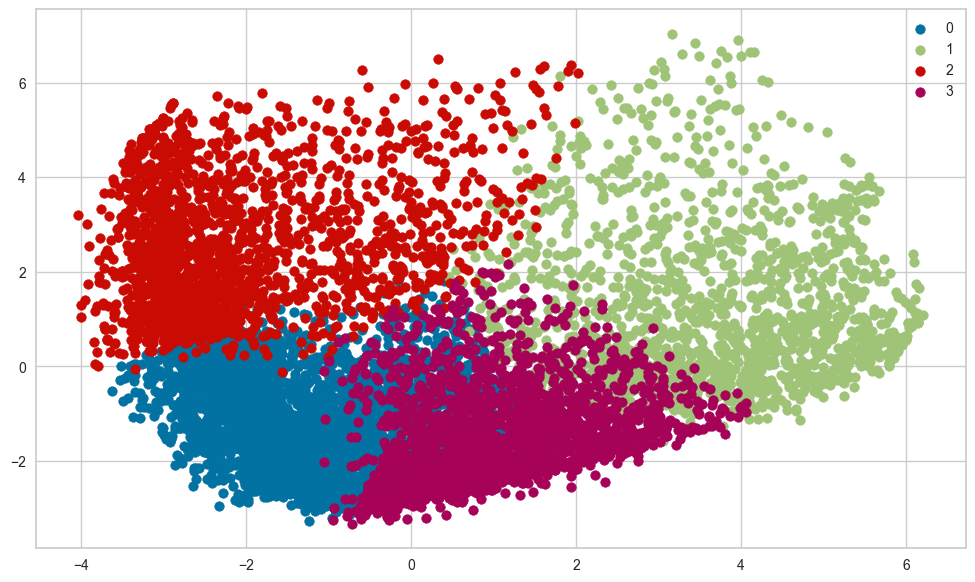

In [ ]:
plt.figure(figsize=(12, 7))
ax = plt.subplot()
group = kmeans_model.labels_
for g in np.unique(group):
    index = np.where(group==g)
    ax.scatter(pca_df.iloc[index].pca1, pca_df.iloc[index].pca2, label=g, cmap="cool")
ax.legend()
plt.show()

## Save and load model

In [ ]:
#Save model
import pickle #import thư viện pickle

file_name = "model.sav" #Tạo tên cũng như đường dẫn lưu model (nếu chỉ để tên model không thì sẽ lưu tại thư mục hiện hành)
pickle.dump(kmeans_model, open(file_name, "wb")) #nhận vào tên thư viện và đường dẫn lưu trữ model

file_name = "scaler.sav" #Tạo tên cũng như đường dẫn lưu model (nếu chỉ để tên model không thì sẽ lưu tại thư mục hiện hành)
pickle.dump(scaler, open(file_name, "wb")) #nhận vào tên thư viện và đường dẫn lưu trữ model

In [ ]:
#Load model
file_name = "model.sav"
model = pickle.load(open(file_name, "rb"))

file_name = "scaler.sav"
scaler = pickle.load(open(file_name, "rb"))

# Discussion & Conclusion

### Discussion

Trong quá trình phân tích, tôi nhận thấy dữ liệu chứa nhiều giá trị ngoại lai (outliers). Do đó, tôi đã áp dụng phương pháp IQR để loại bỏ các điểm bất thường, giúp tăng tính ổn định cho việc phân cụm.

Sau khi chuẩn hóa dữ liệu, tôi áp dụng thuật toán phân cụm KMeans, đồng thời sử dụng PCA (Principal Component Analysis) để giảm chiều dữ liệu nhằm trực quan hóa tốt hơn:

- Biểu đồ Elbow cho thấy số cụm hợp lý là k = 4.

- PCA 3D giúp quan sát tổng thể hình dạng các cụm trong không gian 3 chiều. Mặc dù có một số vùng chồng lấn nhẹ, các cụm vẫn phân biệt rõ ở phần lớn không gian.

- PCA 2D biểu diễn mỗi cụm thành khối tương đối đều và tách biệt, cho thấy KMeans đã hoạt động hiệu quả trong việc phân tách dữ liệu.

### Conclusion

Kết quả cho thấy mô hình hoạt động khá tốt:

- Các cụm được tách biệt rõ ràng.

- Phân bố dữ liệu trong mỗi cụm khá đồng đều.

- Một vài cụm có chồng lấn nhẹ, nhưng tổng thể vẫn dễ phân biệt.

Phương pháp này có thể giúp doanh nghiệp hiểu rõ hơn về từng nhóm khách hàng để:

- Thiết kế chương trình khuyến mãi phù hợp.

- Đưa ra quyết định cá nhân hóa dịch vụ.

- Quản lý rủi ro tín dụng hiệu quả hơn.